In [1]:
savepathIMG = "../Images/"
from BCI_Library import plot_violin_all_subj

# Before december, selection MyCriteria on band 4 - 30 Hz

## Personalized freqs vs Standard freqs

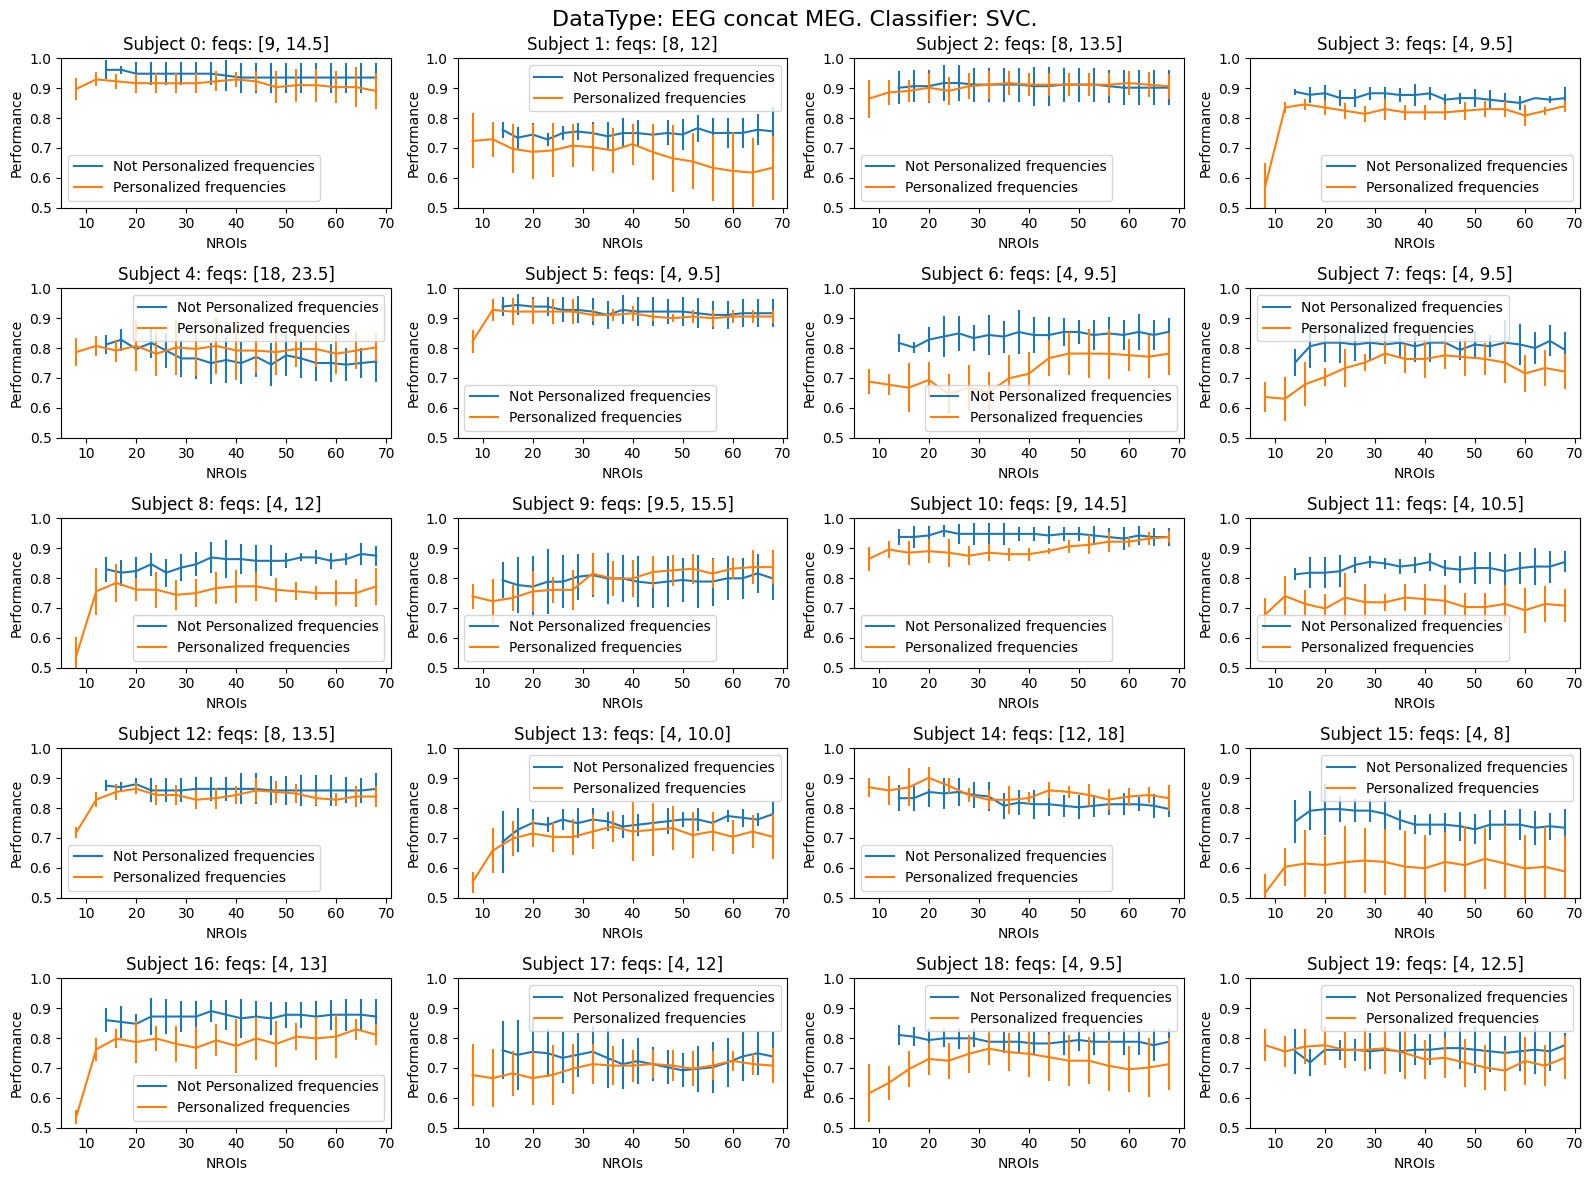

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"DataType":"EEG concat MEG", "Classifier":"SVC"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Personalized_Freq_Range":False})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="Not Personalized frequencies")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Personalized_Freq_Range":True})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="Personalized frequencies")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}: feqs: {freq_personalized[f'subject_{subject}']}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Performance")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"freq_personalized_vs_not_SVM.png")
plt.show()

## Different Classifiers - Fixed Datatypes

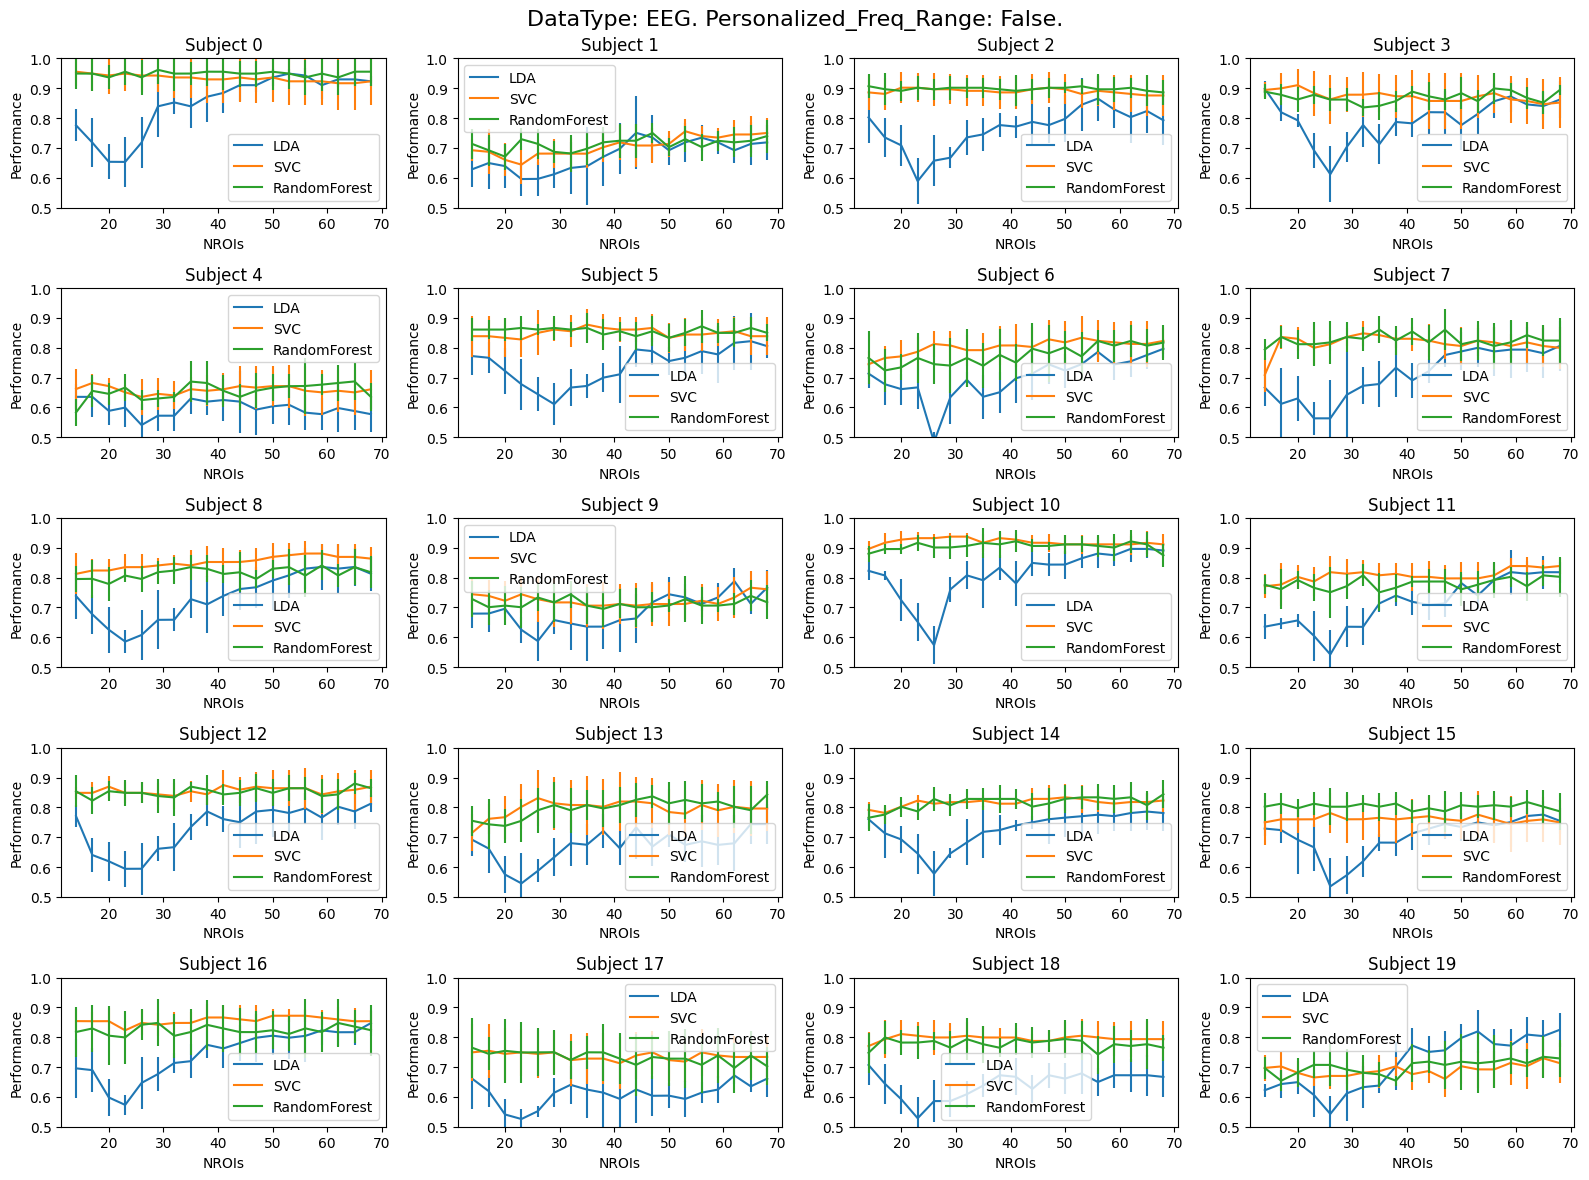

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"DataType":"EEG","Personalized_Freq_Range":False}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":"LDA"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="LDA")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":"SVC"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="SVC")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":"RandomForest"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="RandomForest")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Performance")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"EEG_notPersonalised_vs_Classifier.png")
plt.show()

## Different Datatypes - Fixed Classifiers

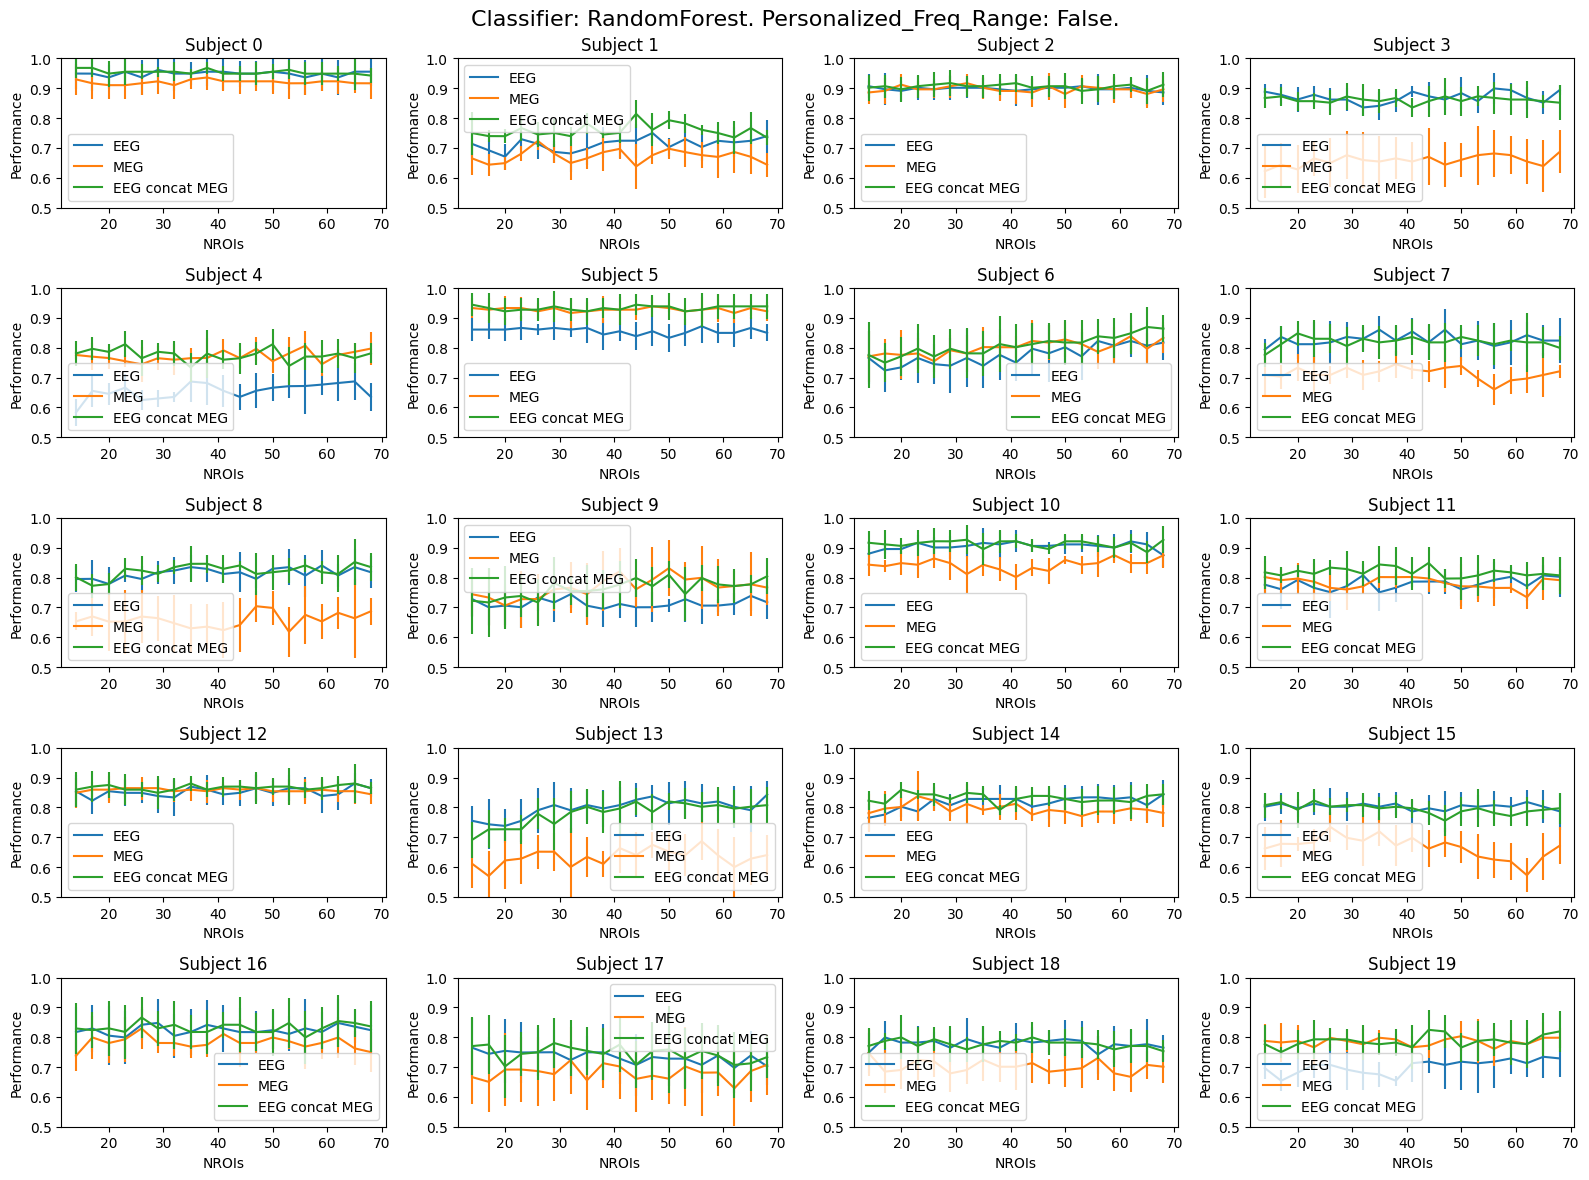

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"RandomForest","Personalized_Freq_Range":False,}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "DataType":"EEG", "Comments":"-"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="EEG")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "DataType":"MEG", "Comments":"-"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="MEG")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "DataType":"EEG concat MEG", "Comments":"ROIs: EEG then MEG"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="EEG concat MEG")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Performance")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"EEG_concat_MEG_vs_EEG_vs_MEG_SVM.png")
plt.show()

In [3]:
rows

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Performance,Features,Comments,Date,Personalized_Freq_Range
2641,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",14.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7894736842105263, 0.8157894736842105, 0.684...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2642,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",17.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7368421052631579, 0.7368421052631579, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2643,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",20.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7631578947368421, 0.7894736842105263, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2644,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",23.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.868421052631579, 0.7368421052631579, 0.7105...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2645,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",26.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7631578947368421, 0.7894736842105263, 0.763...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2646,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",29.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7894736842105263, 0.8157894736842105, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2647,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",32.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.8421052631578947, 0.7368421052631579, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2648,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",35.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.8157894736842105, 0.7894736842105263, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2649,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",38.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7894736842105263, 0.8157894736842105, 0.710...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2650,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",41.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7631578947368421, 0.7894736842105263, 0.710...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False


## Only Mean - Only Max

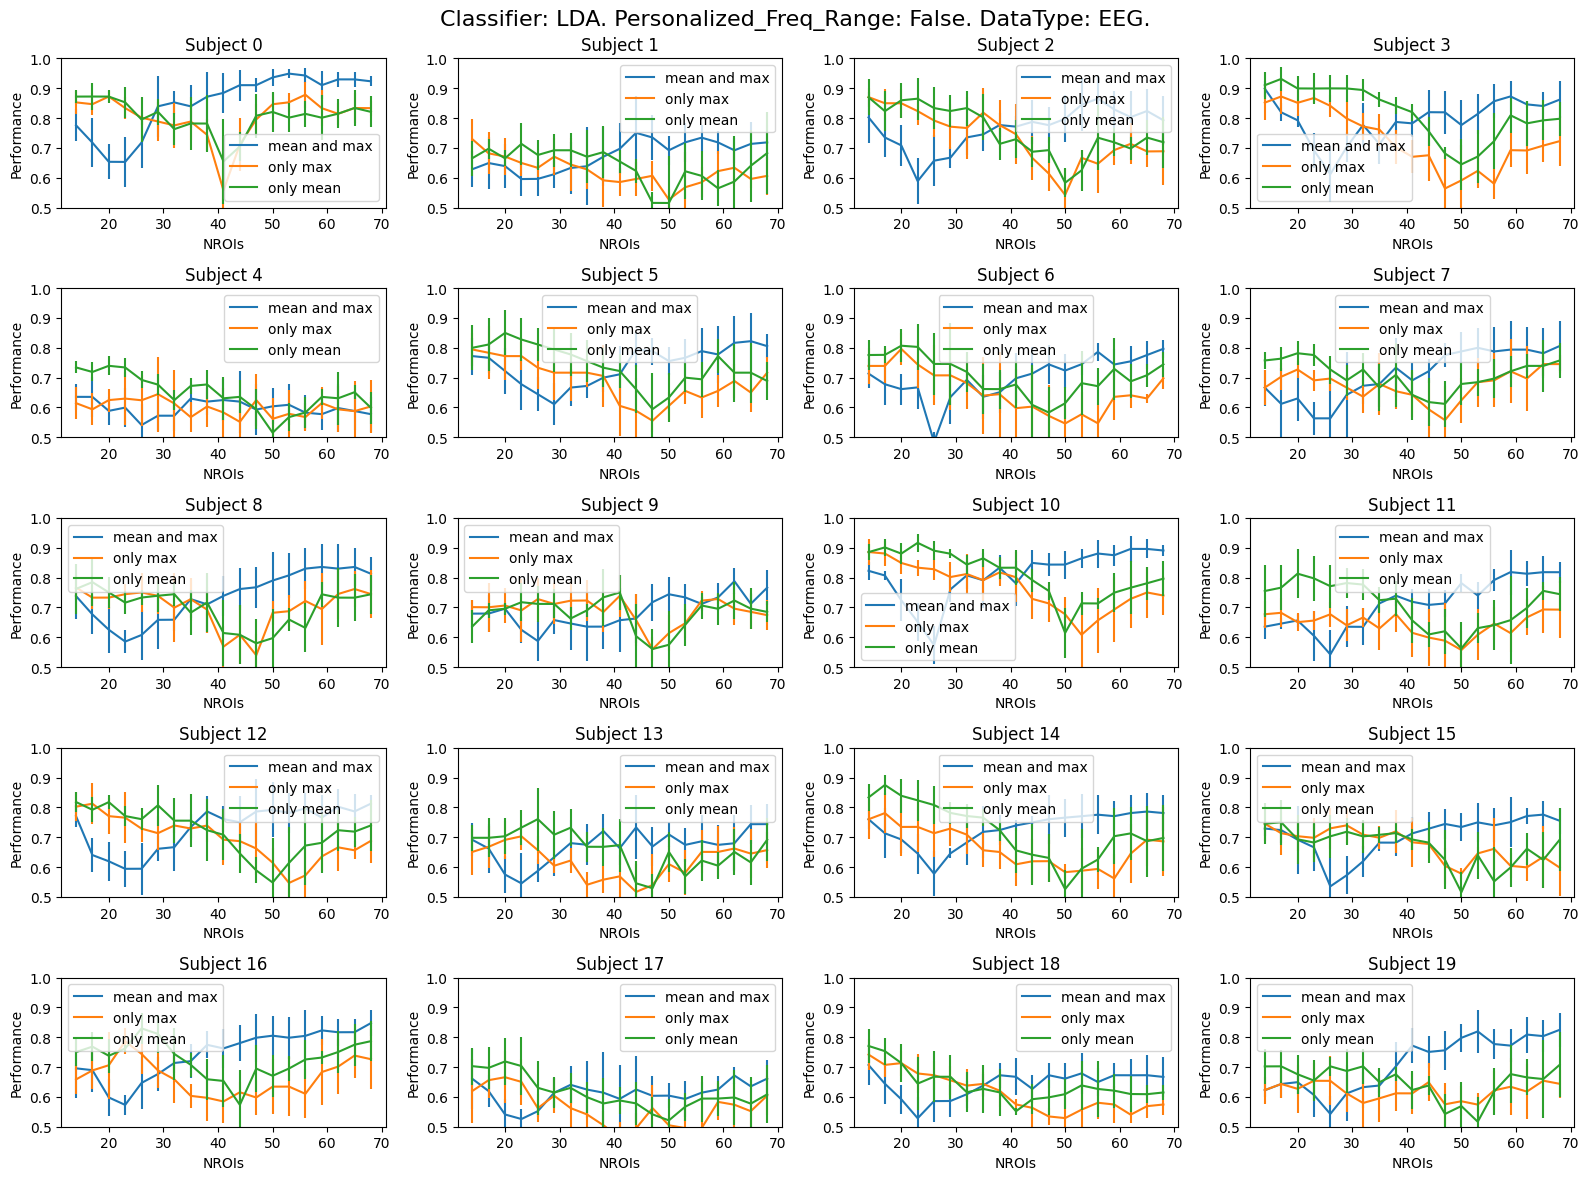

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances.pkl")
PerData2 = pd.read_pickle("../Results/BCI_Performances_ony1Feature.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"LDA","Personalized_Freq_Range":False,"DataType":"EEG"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values 
    ax.plot(nrois, allperf.mean(axis=1),label="mean and max")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData2, dict_fixed_selection | {"subject":subject, "Comments":"Only max"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="only max")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData2, dict_fixed_selection | {"subject":subject, "Comments":"Only mean"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="only mean")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Performance")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
savepathIMG = "../Images/"
plt.savefig(savepathIMG+"Perf_max_mean_EEF_LDA.png")
plt.show()

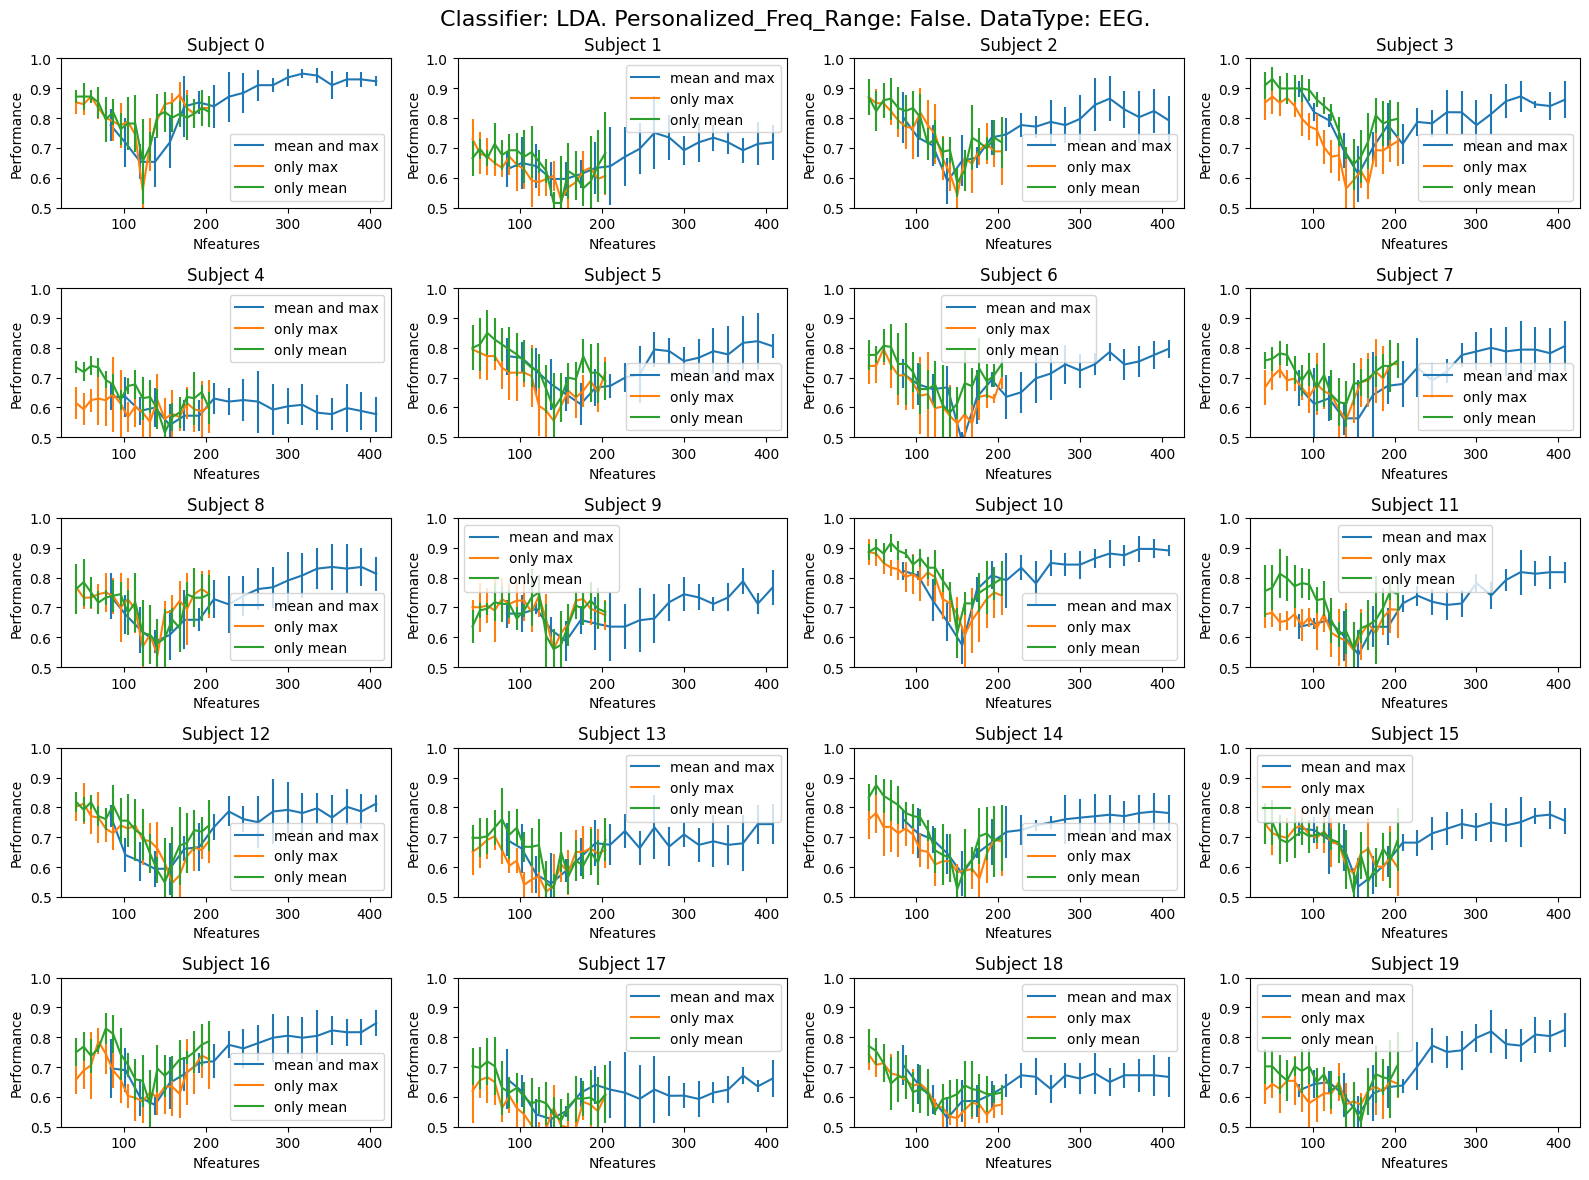

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances.pkl")
PerData2 = pd.read_pickle("../Results/BCI_Performances_ony1Feature.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"LDA","Personalized_Freq_Range":False,"DataType":"EEG"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values * 6
    ax.plot(nrois, allperf.mean(axis=1),label="mean and max")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData2, dict_fixed_selection | {"subject":subject, "Comments":"Only max"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values * 3
    ax.plot(nrois, allperf.mean(axis=1),label="only max")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData2, dict_fixed_selection | {"subject":subject, "Comments":"Only mean"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values * 3
    ax.plot(nrois, allperf.mean(axis=1),label="only mean")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("Nfeatures")
    ax.set_ylabel("Performance")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
savepathIMG = "../Images/"
plt.savefig(savepathIMG+"Perf_max_mean_EEF_LDA_xaxis_Nfeatures.png")
plt.show()

## Retaining important regions vs not

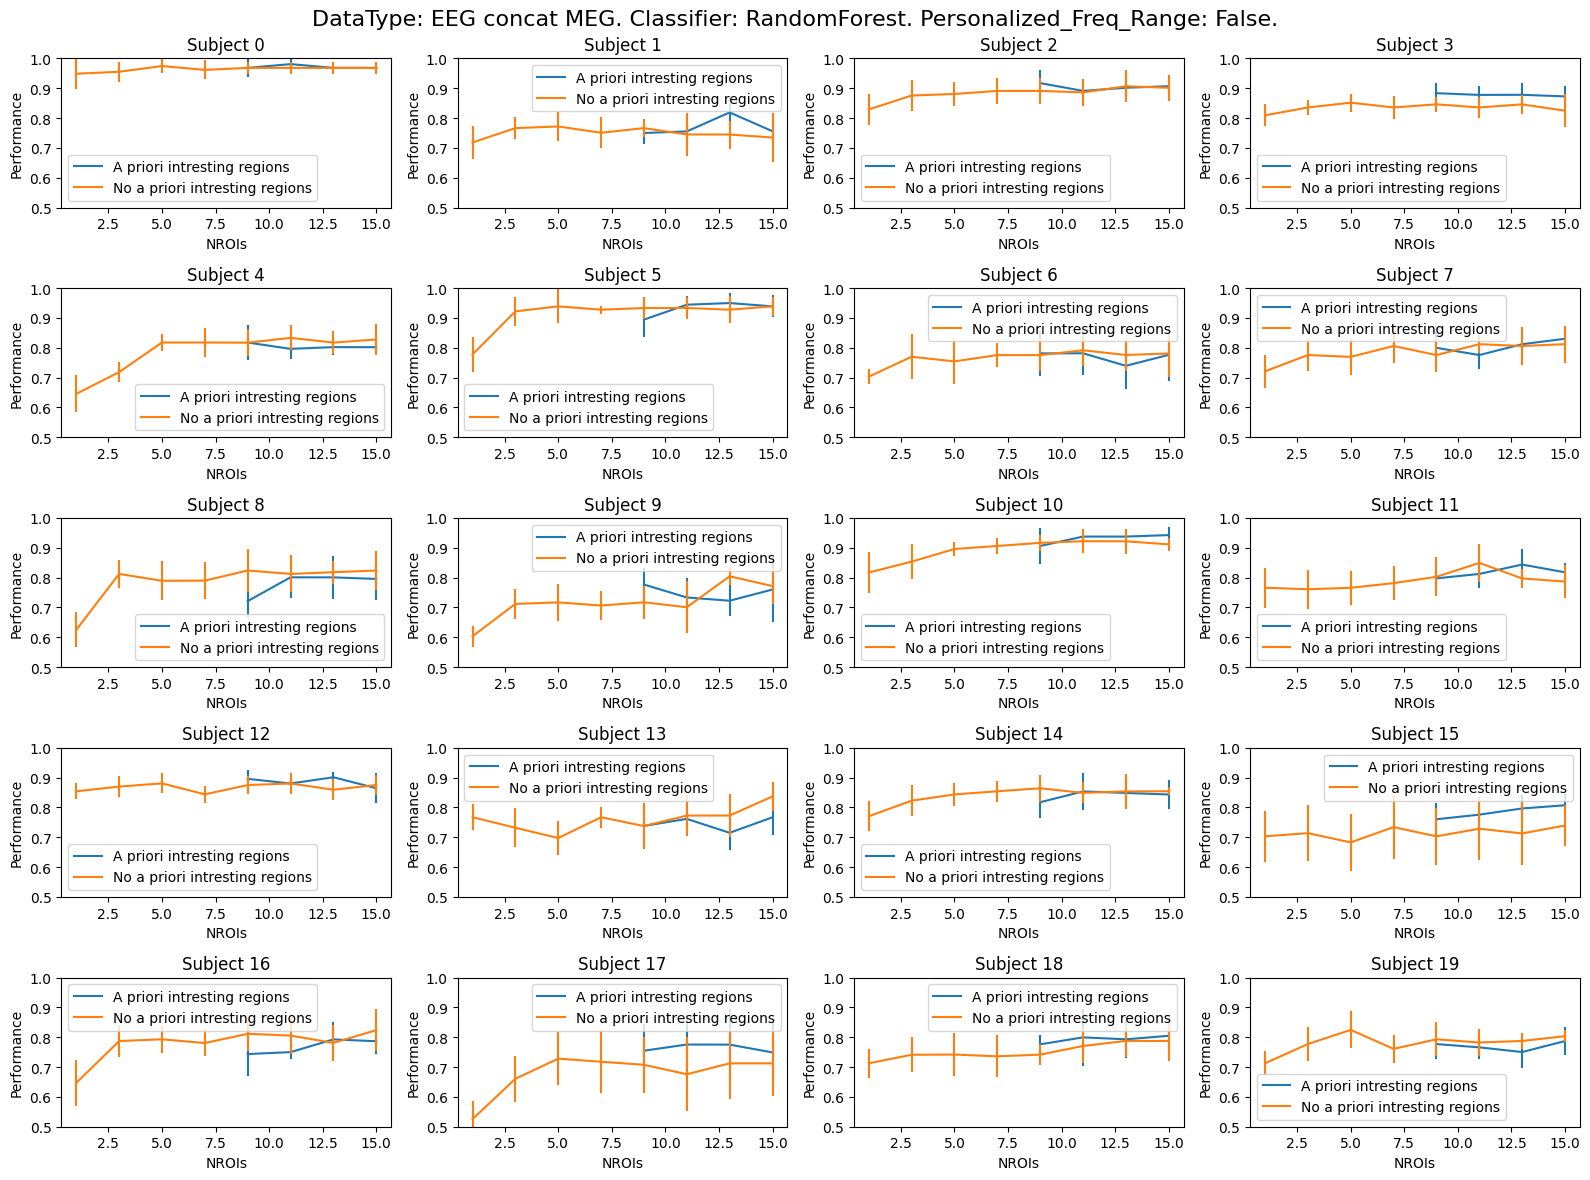

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances_Important_regions_all.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"DataType":"EEG concat MEG", "Classifier":"RandomForest", "Personalized_Freq_Range":False}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Comments":"Yes Important Regions"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="A priori intresting regions")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,  "Comments":"No Interesting Regions"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="No a priori intresting regions")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Performance")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"freq_personalized_vs_not_SVM.png")
plt.show()

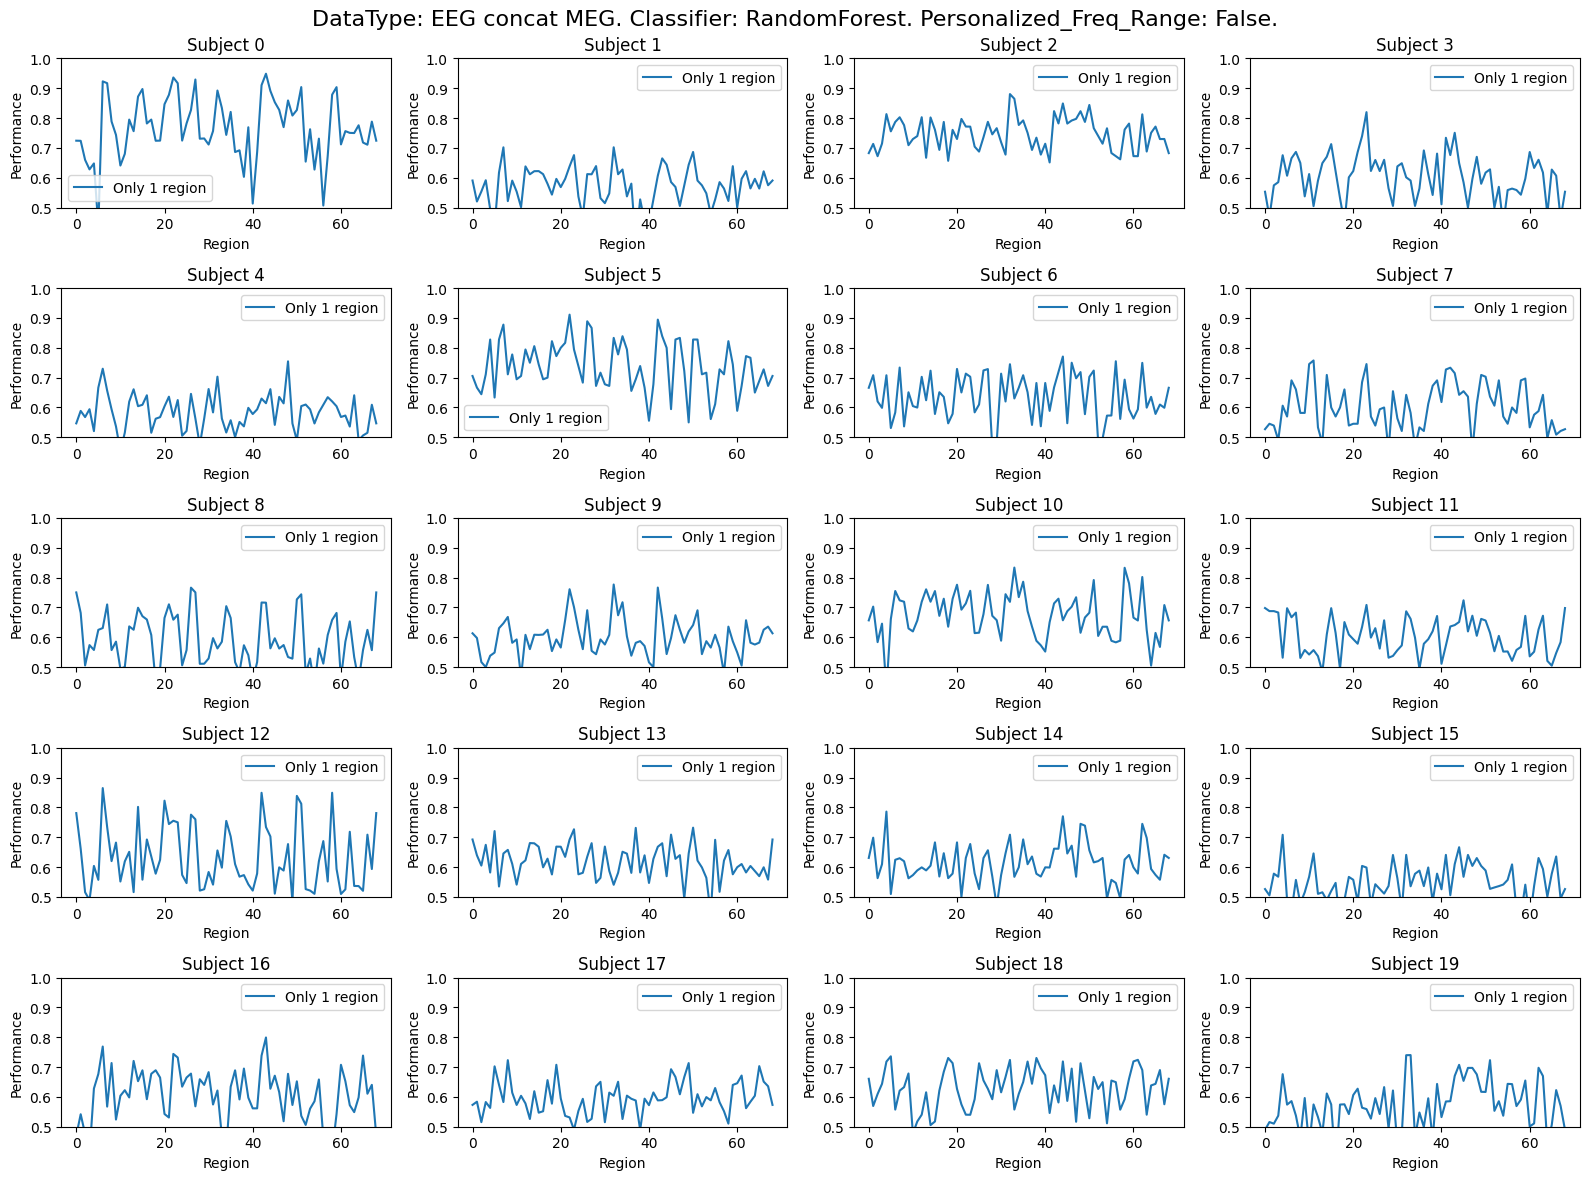

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances_Important_regions_all.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
allallperf = []
dict_fixed_selection = {"DataType":"EEG concat MEG", "Classifier":"RandomForest", "Personalized_Freq_Range":False}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Comments":"Only one region"})
    allperf = np.array(list(rows["Performance"].values))
    allallperf.append(allperf.mean(axis=1))
    nrois = rows["NROIs"].values
    ax.plot( allperf.mean(axis=1),label="Only 1 region")
    #ax.vlines( [i for i in range(68)], allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1',linestyle="--",alpha=0.8)


    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("Region")
    ax.set_ylabel("Performance")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"freq_personalized_vs_not_SVM.png")
plt.show()

In [38]:
allallperf=np.array(allallperf)
allallperf.mean(axis=0).shape

(68,)

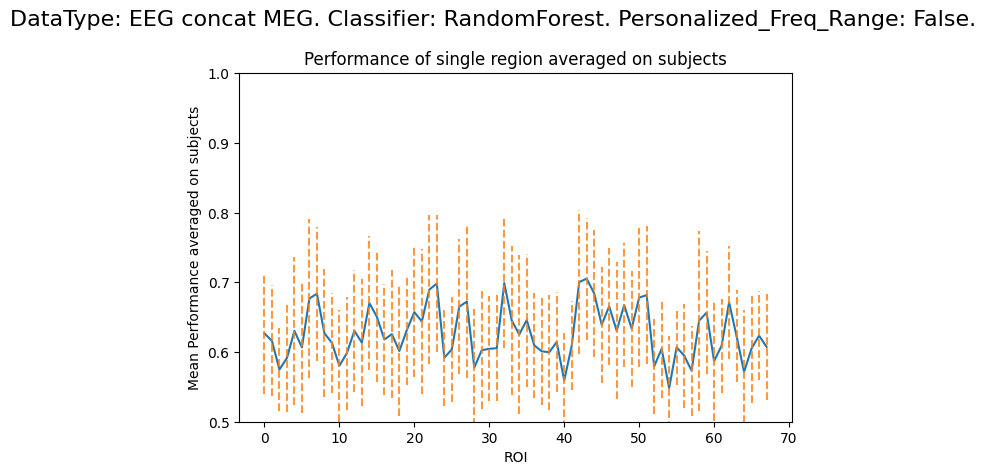

In [39]:
plt.plot(allallperf.mean(axis=0))
plt.vlines( [i for i in range(68)], allallperf.mean(axis=0)-allallperf.std(axis=0), allallperf.mean(axis=0)+allallperf.std(axis=0), colors='C1',linestyle="--",alpha=0.8)


plt.ylim(0.5, 1)
plt.title(f"Performance of single region averaged on subjects")
plt.xlabel("ROI")
plt.ylabel("Mean Performance averaged on subjects")


plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()


## Single graph with every subject vs Classifier-DataType

### regions old method - Interesting + selected

/var/folders/dq/8wtb30zx51b4wvfmgb1_x4rm0000gq/T/ipykernel_32010/3358773110.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", 20)


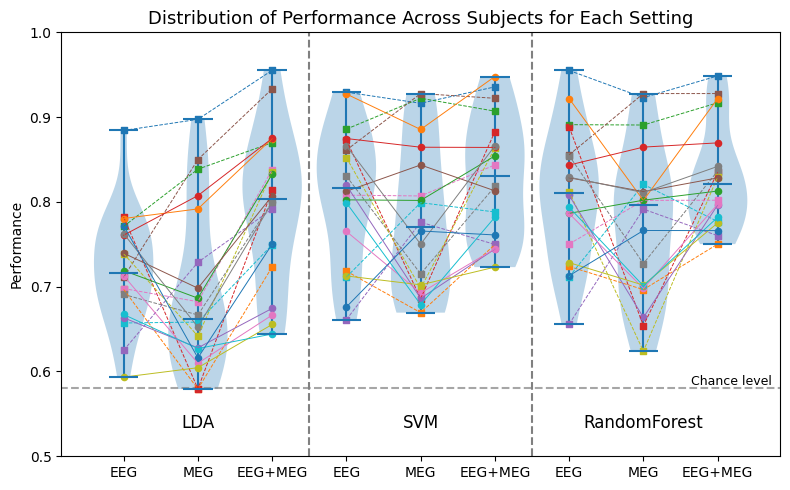

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

chaanche_lvl = 0.58 # https://pubmed.ncbi.nlm.nih.gov/25596422/

VisualizigNROIs=41

PerData = pd.read_pickle("../Results/BCI_Performances.pkl")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

x_positions = np.arange(9)

cmap = plt.cm.get_cmap("tab20", 20)
styles=["--","solid"]
markes=["s","o"]
size=20


classifiers=["LDA","LDA","LDA","SVC","SVC","SVC","RandomForest","RandomForest","RandomForest"]
Datatypes=["EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG"]
x_ticklabels=[_.replace(" concat ","\n+\n") for _ in Datatypes]

all_perfs = []
dict_fixed_selection = {"NROIs":VisualizigNROIs,  "Personalized_Freq_Range":False}
for subject in range(20):

    perfs_per_subject = []
    for setting in range(9):
        # Extract performances
        rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":classifiers[setting], "DataType":Datatypes[setting]})
        perfs_per_subject.append(np.array(list(rows["Performance"].values)).mean())
    all_perfs.append(perfs_per_subject)
    shifcolor=1 if subject>=10 else 0
    color=f"C{subject+shifcolor}"

    ax.scatter(x_positions, perfs_per_subject, marker=markes[subject//10],s=size,color=color)#facecolors='none',edgecolors=color
    ax.plot(x_positions[0:3], perfs_per_subject[0:3], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[3:6], perfs_per_subject[3:6], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[6:9], perfs_per_subject[6:9], linestyle=styles[subject//10], linewidth=0.7,color=color)
    
all_perfs = np.array(all_perfs)   # shape (20 subjects, 9 settings)

#Violin plot
ax_violin = ax
violins = ax_violin.violinplot(
    all_perfs,
    positions=x_positions,
    showmeans=False,
    showmedians=True,
    widths=0.8,
)

for part in violins['bodies']+[violins['cbars']]:
    part.set_zorder(-20)
xlims = ax.get_xlim()
ax_violin.set_ylabel("Performance")
ax.hlines(chaanche_lvl, -1, 9, colors='grey', linestyles='dashed', label="Chance Level",zorder=-1, alpha=0.7)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_ticklabels)
ax.vlines([2.5,5.5], 0.5, 1, colors='gray', linestyles='dashed')
ax.set_ylim(0.5, 1)
ax.text(0.19, 0.1, f"LDA", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.5, 0.1, f"SVM", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.81, 0.1, f"RandomForest", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(1., 0.192, f"Chance level  ", transform=ax.transAxes, fontsize=9, verticalalignment='top',horizontalalignment='right')
ax.set_title("Distribution of Performance Across Subjects for Each Setting", fontsize=13)
ax.set_xlim(xlims)
plt.tight_layout()
plt.savefig(savepathIMG+"Performance_vs_Setting_41_ROIs.png",dpi=300)
plt.show()

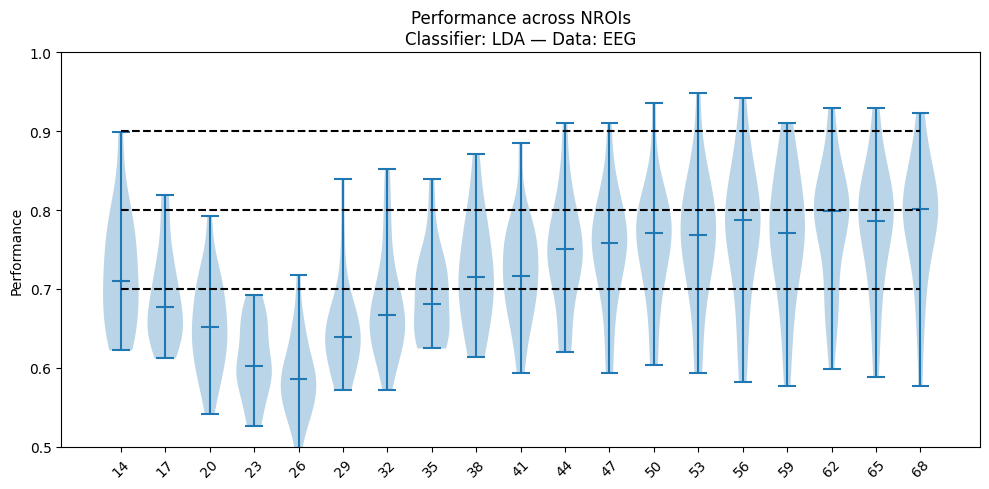

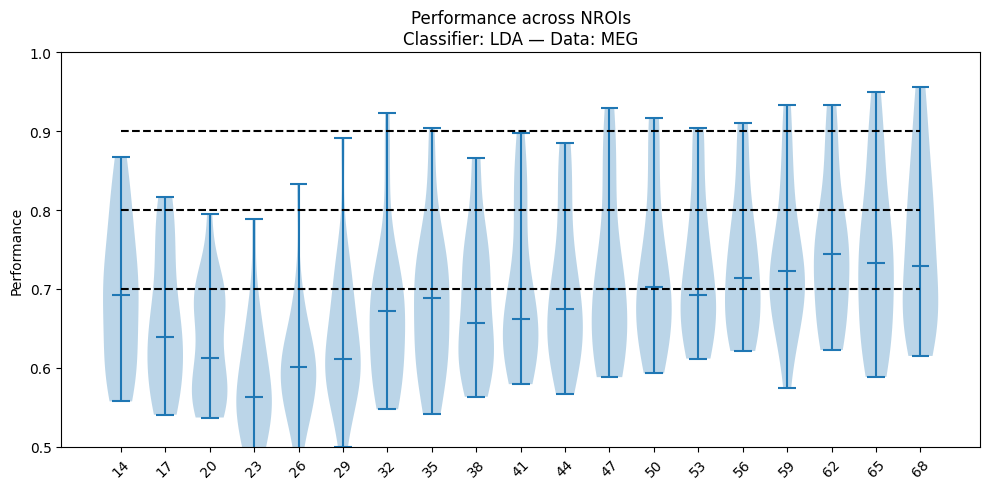

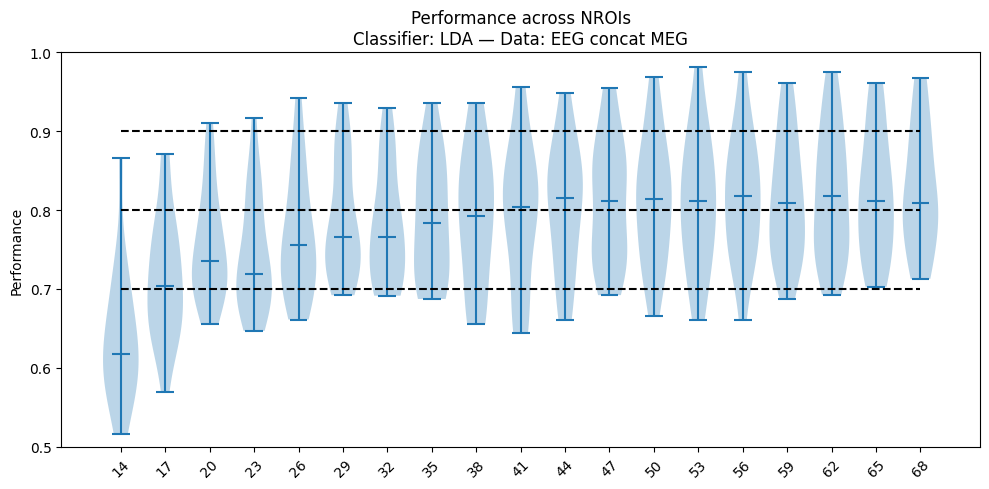

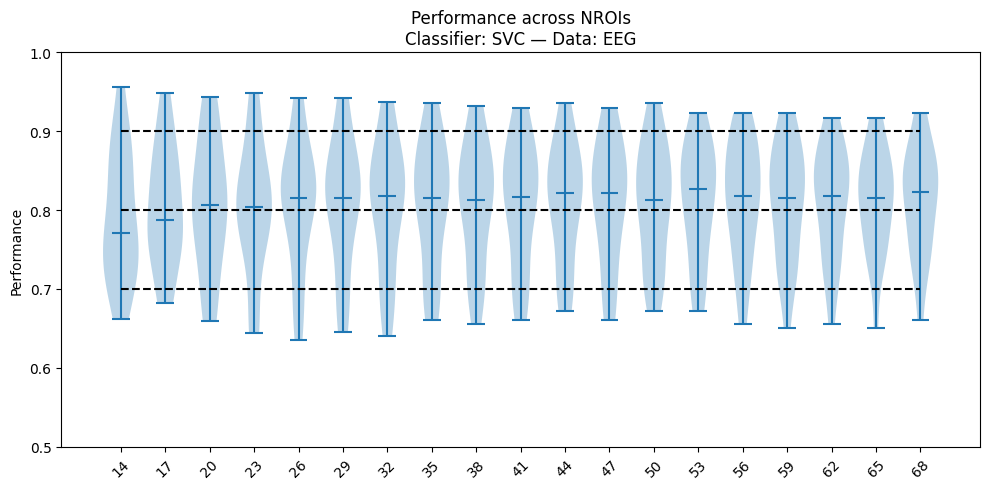

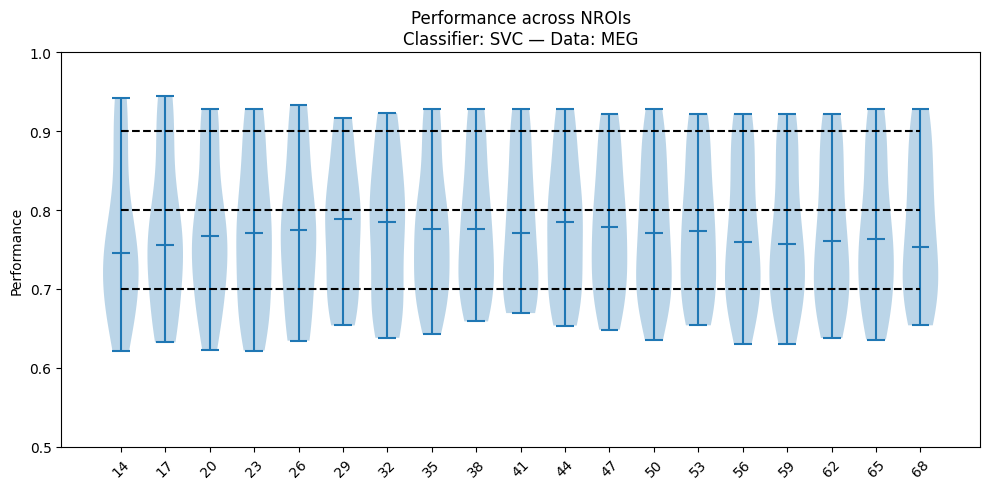

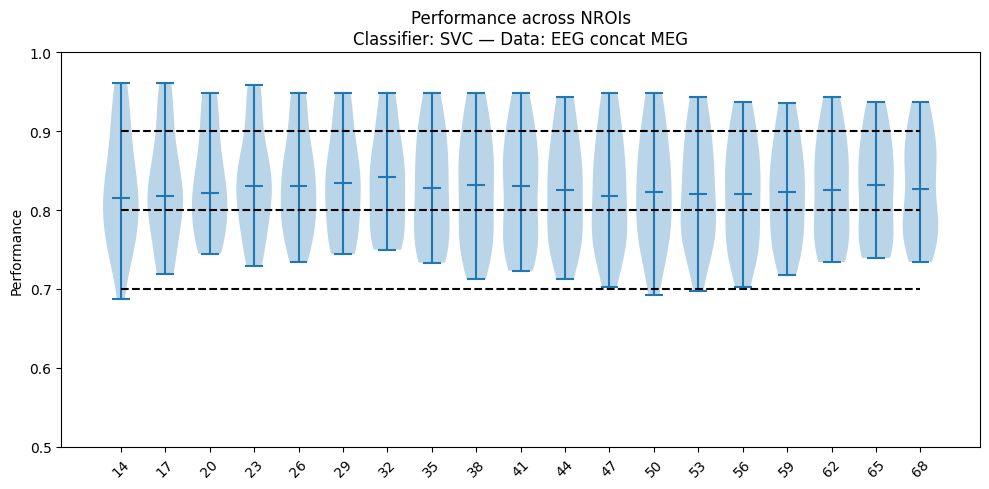

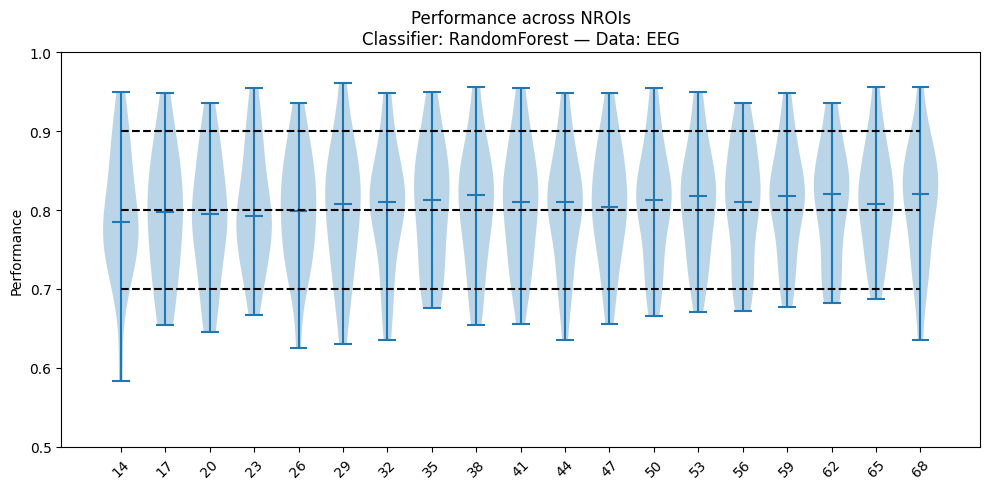

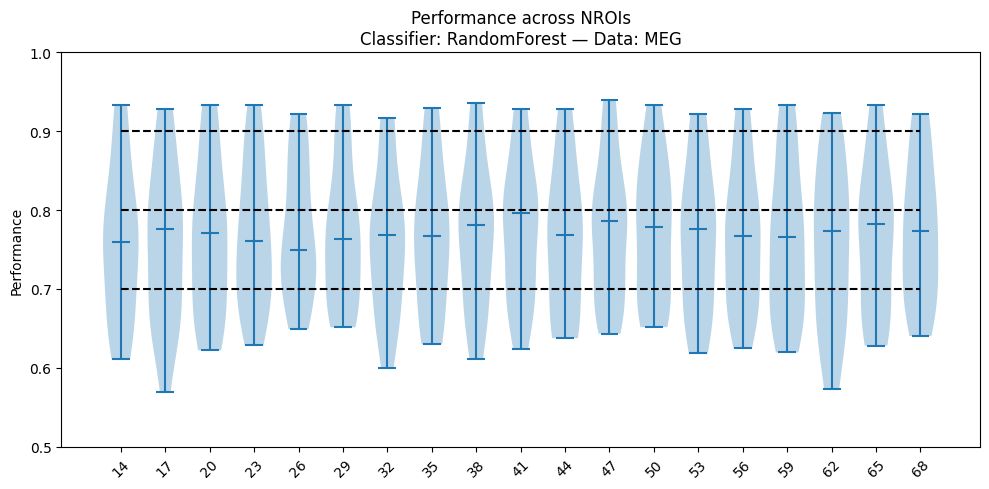

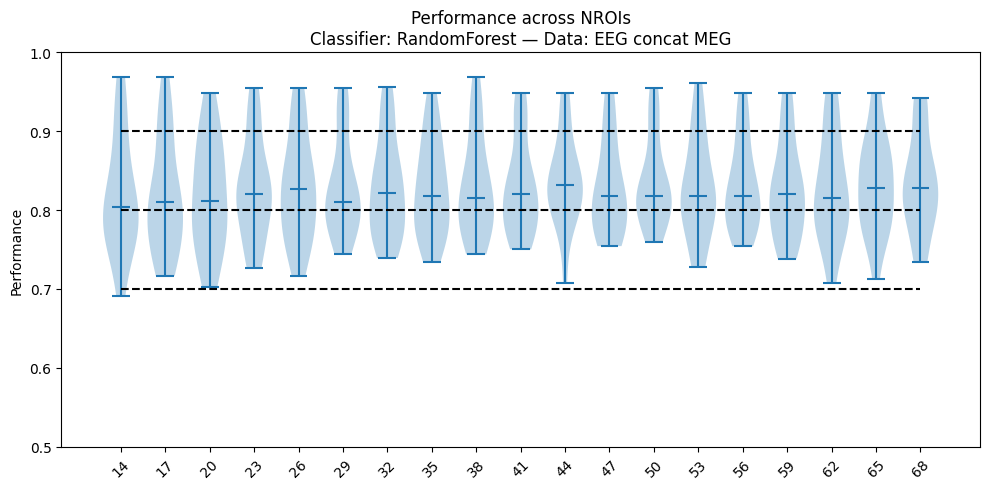

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows

# Load data
PerData = pd.read_pickle("../Results/BCI_Performances.pkl")

# Settings
classifiers = ["LDA","LDA","LDA","SVC","SVC","SVC","RandomForest","RandomForest","RandomForest"]
Datatypes   = ["EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG"]

# Vary these
all_NROIs = list(range(14, 69, 3))     # e.g., 14,17,20,...,68
subjects = range(20)

# ============ MAIN PLOT LOOP ============
for setting in range(9):

    clf  = classifiers[setting]
    dtype = Datatypes[setting]

    # Collect performance distributions across NROIs
    # final shape = (len(NROIs), n_subjects)
    all_violins = []

    for NROIs in all_NROIs:
        dict_fixed = {
            "NROIs": NROIs,
            "Personalized_Freq_Range": False
        }

        perfs_for_this_NROIs = []

        for subject in subjects:
            rows = select_rows(
                PerData,
                dict_fixed | {"subject": subject,
                              "Classifier": clf,
                              "DataType": dtype}
            )
            perf = np.array(list(rows["Performance"].values)).mean()
            perfs_for_this_NROIs.append(perf)

        all_violins.append(perfs_for_this_NROIs)

    all_violins = np.array(all_violins).T   # shape becomes (subjects, NROIs) for violinplot

    # ================== PLOT =======================
    fig, ax = plt.subplots(figsize=(10, 5))

    positions = np.arange(len(all_NROIs))

    violins = ax.violinplot(
        all_violins,
        positions=positions,
        showmeans=False,
        showmedians=True,
        widths=0.8
    )
    ax.hlines([0.7,0.8,0.9],0,18, color="black", linestyles='dashed')

    # optional: push violins behind scatter or other elements
    for body in violins['bodies']:
        body.set_zorder(-20)

    # Labels
    ax.set_title(f"Performance across NROIs\nClassifier: {clf} — Data: {dtype}")
    ax.set_ylabel("Performance")
    ax.set_xticks(positions)
    ax.set_xticklabels(all_NROIs, rotation=45)
    ax.set_ylim(0.5, 1.0)

    plt.tight_layout()
    plt.show()


### Only interesting regions

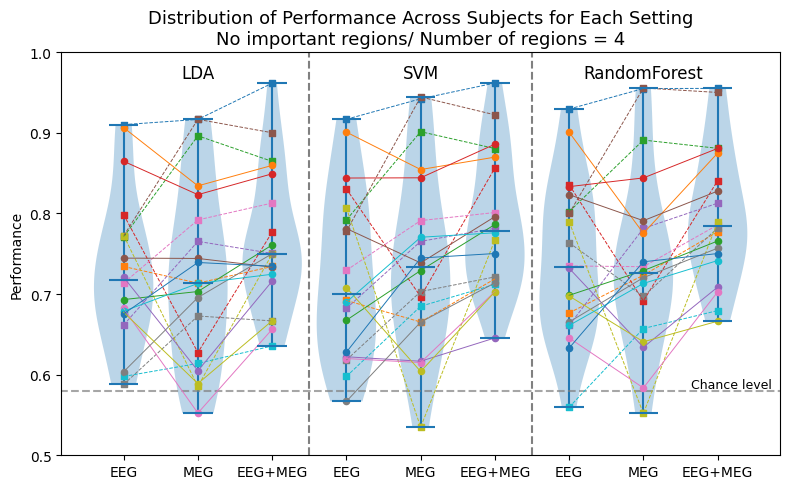

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,         EEG - MEG - concat (Concat da fare)
# Classifier,       LDA - SVC - Random
# NROIs,            4lh - 4rh - 4lh+4rh - 4free - 8free 
        # Yes important regions - left
        # Yes important regions - right
        # Yes important regions - all
        # No important regions 
# subject, 
# Personalized_Freq_Range

chaanche_lvl = 0.58 # https://pubmed.ncbi.nlm.nih.gov/25596422/

# TODO change here 
VisualizigNROIs=4
comment="No important regions"


dict_fixed_selection = {"NROIs":VisualizigNROIs,  "Personalized_Freq_Range":False, "Comments":comment}
PerData = pd.read_pickle("../Results/BCI_Performances_Important_regions.pkl")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

x_positions = np.arange(9)


styles=["--","solid"]
markes=["s","o"]
size=20


classifiers=["LDA","LDA","LDA","SVC","SVC","SVC","RandomForest","RandomForest","RandomForest"]
Datatypes=["EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG"]


x_ticklabels=[_.replace(" concat ","\n+\n") for _ in Datatypes]

all_perfs = []
for subject in range(20):

    perfs_per_subject = []
    for setting in range(9):
        # Extract performances
        rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":classifiers[setting], "DataType":Datatypes[setting]})
        perfs_per_subject.append(np.array(list(rows["Performance"].values)).mean())
    all_perfs.append(perfs_per_subject)
    shifcolor=1 if subject>=10 else 0
    color=f"C{subject+shifcolor}"

    ax.scatter(x_positions, perfs_per_subject, marker=markes[subject//10],s=size,color=color)#facecolors='none',edgecolors=color
    ax.plot(x_positions[0:3], perfs_per_subject[0:3], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[3:6], perfs_per_subject[3:6], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[6:9], perfs_per_subject[6:9], linestyle=styles[subject//10], linewidth=0.7,color=color)
    
all_perfs = np.array(all_perfs)   # shape (20 subjects, 9 settings)

#Violin plot
ax_violin = ax
violins = ax_violin.violinplot(
    all_perfs,
    positions=x_positions,
    showmeans=False,
    showmedians=True,
    widths=0.8,
)

for part in violins['bodies']+[violins['cbars']]:
    part.set_zorder(-20)
xlims = ax.get_xlim()
ax_violin.set_ylabel("Performance")
ax.hlines(chaanche_lvl, -1, 9, colors='grey', linestyles='dashed', label="Chance Level",zorder=-1, alpha=0.7)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_ticklabels)
ax.vlines([2.5,5.5], 0.5, 1, colors='gray', linestyles='dashed')
ax.set_ylim(0.5, 1)
ax.text(0.19, 0.97, f"LDA", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.5, 0.97, f"SVM", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.81, 0.97, f"RandomForest", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(1., 0.192, f"Chance level  ", transform=ax.transAxes, fontsize=9, verticalalignment='top',horizontalalignment='right')
ax.set_title(f"Distribution of Performance Across Subjects for Each Setting\n{comment}/ Number of regions = {VisualizigNROIs}", fontsize=13)
ax.set_xlim(xlims)
plt.tight_layout()
plt.savefig(savepathIMG+"Performance_vs_Setting_no_important_4.png",dpi=300)
plt.show()

In [10]:
set(PerData.Comments)

{'No Interesting Regions',
 'No important regions',
 'Only one region',
 'Yes Important Regions',
 'Yes important regions - all',
 'Yes important regions - left',
 'Yes important regions - right'}

## How many times i select a ROI? - Among subjects - Plot on the brain

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows, plot_brain
from matplotlib.colors import LinearSegmentedColormap

# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,
colors = {"EEG":"green","MEG":"blue"}


for DataType in ["EEG",]:
    for NROIs in [17]:#[14,29,41]:
        cmap = LinearSegmentedColormap.from_list("wt", ["white",colors[DataType]])
        
        how_many_times = {}
        

        dict_fixed_selection = {"NROIs":NROIs,"Personalized_Freq_Range":False, "Classifier":"SVC", "DataType":DataType}
        PerData = pd.read_pickle("../Results/BCI_Performances.pkl")
        rows = select_rows(PerData, dict_fixed_selection)

        allRois=[]
        for i in rows["ROIs"].values:
            allRois+=i

        for roi in allRois:
            how_many_times[str(roi)] = how_many_times.get(str(roi), 0) + 1
        for roi in range(68):
            how_many_times[str(roi)] = how_many_times.get(str(roi), 0)

        crs = [cmap(_/20) for _ in how_many_times.values()]

        vvs = ['lateral','medial','rostral','caudal','dorsal']
        my_brain=plot_brain([int(_) for _ in how_many_times.keys()],
                            brain_object_dict={"title":f"{DataType}_NROIs{NROIs}","hemi": "both", "views":vvs}, colors=crs,
                            )
        plotter = my_brain._renderer.plotter

        # STEP 2 — Add text using the plotter (it now applies to renderer 0)
        plotter.add_text(
            f"{DataType}_NROIs{NROIs}",
            position="upper_left",
            font_size=12,
            color="black",
        )

        my_brain.add_text(0,0.5,"fja")

        #my_brain.save_image(savepathIMG+f"Brain_{DataType}_NROIs{NROIs}.png")



Using pyvistaqt 3d backend.
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows, plot_brain
from matplotlib.colors import LinearSegmentedColormap

# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,
colors = {"EEG":"green","MEG":"blue"}

PerData = pd.read_pickle("../Results/BCI_Performances_Important_regions.pkl")

for DataType in ["EEG","MEG"]:
    for NROIs in [4,8]:#[14,29,41]:
        cmap = LinearSegmentedColormap.from_list("wt", ["white",colors[DataType]])
        
        how_many_times = {}
        

        dict_fixed_selection = {"NROIs":NROIs,"Personalized_Freq_Range":False, "Classifier":"SVC", "DataType":DataType,"Comments":"No important regions"}
        
        rows = select_rows(PerData, dict_fixed_selection)

        allRois=[]
        for i in rows["ROIs"].values:
            allRois+=i

        for roi in allRois:
            how_many_times[str(roi)] = how_many_times.get(str(roi), 0) + 1
        for roi in range(68):
            how_many_times[str(roi)] = how_many_times.get(str(roi), 0)

        crs = [cmap(_/7) for _ in how_many_times.values()]

        vvs = ['lateral','medial','rostral','caudal','dorsal']
        my_brain=plot_brain([int(_) for _ in how_many_times.keys()],
                            brain_object_dict={"title":f"{DataType}_NROIs_{NROIs}","hemi": "both", "views":vvs}, colors=crs,
                            )
        plotter = my_brain._renderer.plotter

        # STEP 2 — Add text using the plotter (it now applies to renderer 0)
        plotter.add_text(
            f"{DataType}_NROIs_{NROIs}",
            position="upper_left",
            font_size=12,
            color="black",
        )

        #my_brain.add_text(0,0.5,"fja")
        print(DataType, NROIs, max(how_many_times.values()))
        my_brain.save_image(savepathIMG+f"Brain_no_important_regions_{DataType}_NROIs_{NROIs}.png")



Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot
EEG 4 5
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot
EEG 8 7
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot
MEG 4 4
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/m

In [11]:
sum(how_many_times.values())

160

In [10]:
rows

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Performance,Features,Comments,Date,Personalized_Freq_Range
1661,"[23, 15, 14, 22, 17, 51, 50, 58]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",0.0,SVC,"[0.875, 0.967741935483871, 0.9354838709677419,...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1663,"[67, 61, 43, 59, 42, 51, 26, 7]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",1.0,SVC,"[0.7631578947368421, 0.7105263157894737, 0.736...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1665,"[42, 14, 43, 23, 26, 27, 48, 6]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",2.0,SVC,"[0.7692307692307693, 0.8205128205128205, 0.815...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1667,"[23, 15, 10, 7, 43, 22, 42, 14]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",3.0,SVC,"[0.7368421052631579, 0.868421052631579, 0.8421...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1669,"[16, 41, 22, 30, 7, 44, 10, 12]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",4.0,SVC,"[0.5641025641025641, 0.5897435897435898, 0.736...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1671,"[33, 32, 44, 56, 11, 55, 28, 10]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",5.0,SVC,"[0.7777777777777778, 0.8611111111111112, 0.666...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1673,"[48, 36, 56, 44, 49, 45, 54, 24]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",6.0,SVC,"[0.7692307692307693, 0.6153846153846154, 0.736...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1675,"[7, 59, 49, 45, 15, 50, 33, 42]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",7.0,SVC,"[0.696969696969697, 0.6666666666666666, 0.7272...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1677,"[23, 26, 15, 43, 22, 27, 6, 34]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",8.0,SVC,"[0.7777777777777778, 0.8, 0.8, 0.7142857142857...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1679,"[65, 55, 53, 31, 59, 23, 61, 7]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",9.0,SVC,"[0.6216216216216216, 0.6486486486486487, 0.702...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False


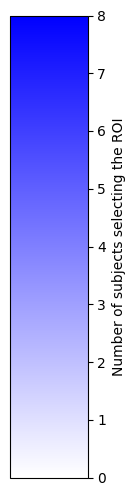

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colorbar import ColorbarBase

cmap = LinearSegmentedColormap.from_list("white_to_green", ["white", "blue"])
norm = Normalize(vmin=0, vmax=8)
fig, ax = plt.subplots(figsize=(1, 6))  # tall figure for vertical colorbar
ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', label='Number of subjects selecting the ROI')
#plt.show()
plt.savefig(f"{savepathIMG}colorbar_white_to_blue_max8.png", dpi=300, bbox_inches='tight')


## Frequencies selection

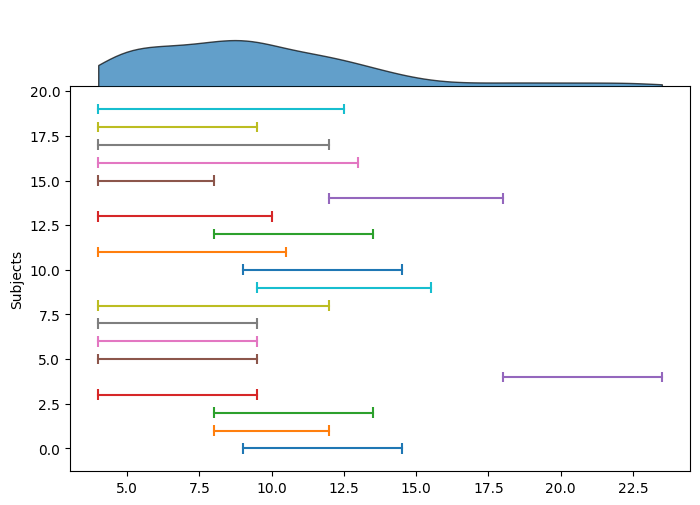

In [31]:
import matplotlib.pyplot as plt
import numpy as np

freq_personalized = {
    "subject_0":[9,14.5], "subject_1":[8,12], "subject_2":[8,13.5],
    "subject_3":[4,9.5], "subject_4":[18,23.5], "subject_5":[4,9.5],
    "subject_6":[4,9.5], "subject_7":[4,9.5], "subject_8":[4,12],
    "subject_9":[9.5,15.5], "subject_10":[9,14.5], "subject_11":[4,10.5],
    "subject_12":[8,13.5], "subject_13":[4,10.], "subject_14":[12,18],
    "subject_15":[4,8], "subject_16":[4,13], "subject_17":[4,12],
    "subject_18":[4,9.5], "subject_19":[4,12.5],
}

# Flatten all frequency ranges for cumulative violin
all_freqs = []
for subj in freq_personalized.values():
    all_freqs.extend(np.linspace(subj[0], subj[1], 50))
all_freqs = np.array(all_freqs)

fig, ax_main = plt.subplots(1,1, figsize=(8,5))
# Main plot: individual subjects
for subject in range(20):
    ax_main.plot(freq_personalized[f"subject_{subject}"], [subject,subject], color=f"C{subject}")
    ax_main.vlines(freq_personalized[f"subject_{subject}"], subject-0.3, subject+0.3, color=f"C{subject}")
ax_main.set_ylabel("Subjects")



# Create twin axis sharing x-axis but at the bottom
ax_violin = ax_main.inset_axes([0,1, 1, 0.2])  # x0, y0, width, height in axis fraction

viol = ax_violin.violinplot(all_freqs, positions=[0], widths=1.2,
                            showmeans=False, showmedians=False, showextrema=False, vert=False)

for i, body in enumerate(viol['bodies']):
    verts = body.get_paths()[0].vertices
    if i == 0:
        # one half
        verts[:,1] = np.clip(verts[:,1], 0, None)
        body.set_facecolor('C0')
    else:
        # other  half
        verts[:,1] = np.clip(verts[:,1], None, 0)
        body.set_facecolor('C0')
    body.set_edgecolor('black')
    body.set_alpha(0.7)

ax_violin.set_yticks([])
ax_violin.set_xticks([])
ax_violin.set_ylim(0,1)
# ax_violin.set_xlabel("Frequencies (Hz)")
ax_violin.set_xlim(ax_main.get_xlim())
ax_violin.set_frame_on(False)


plt.show()


# Different region selection criteria - starting on December 2025


## Per Subject

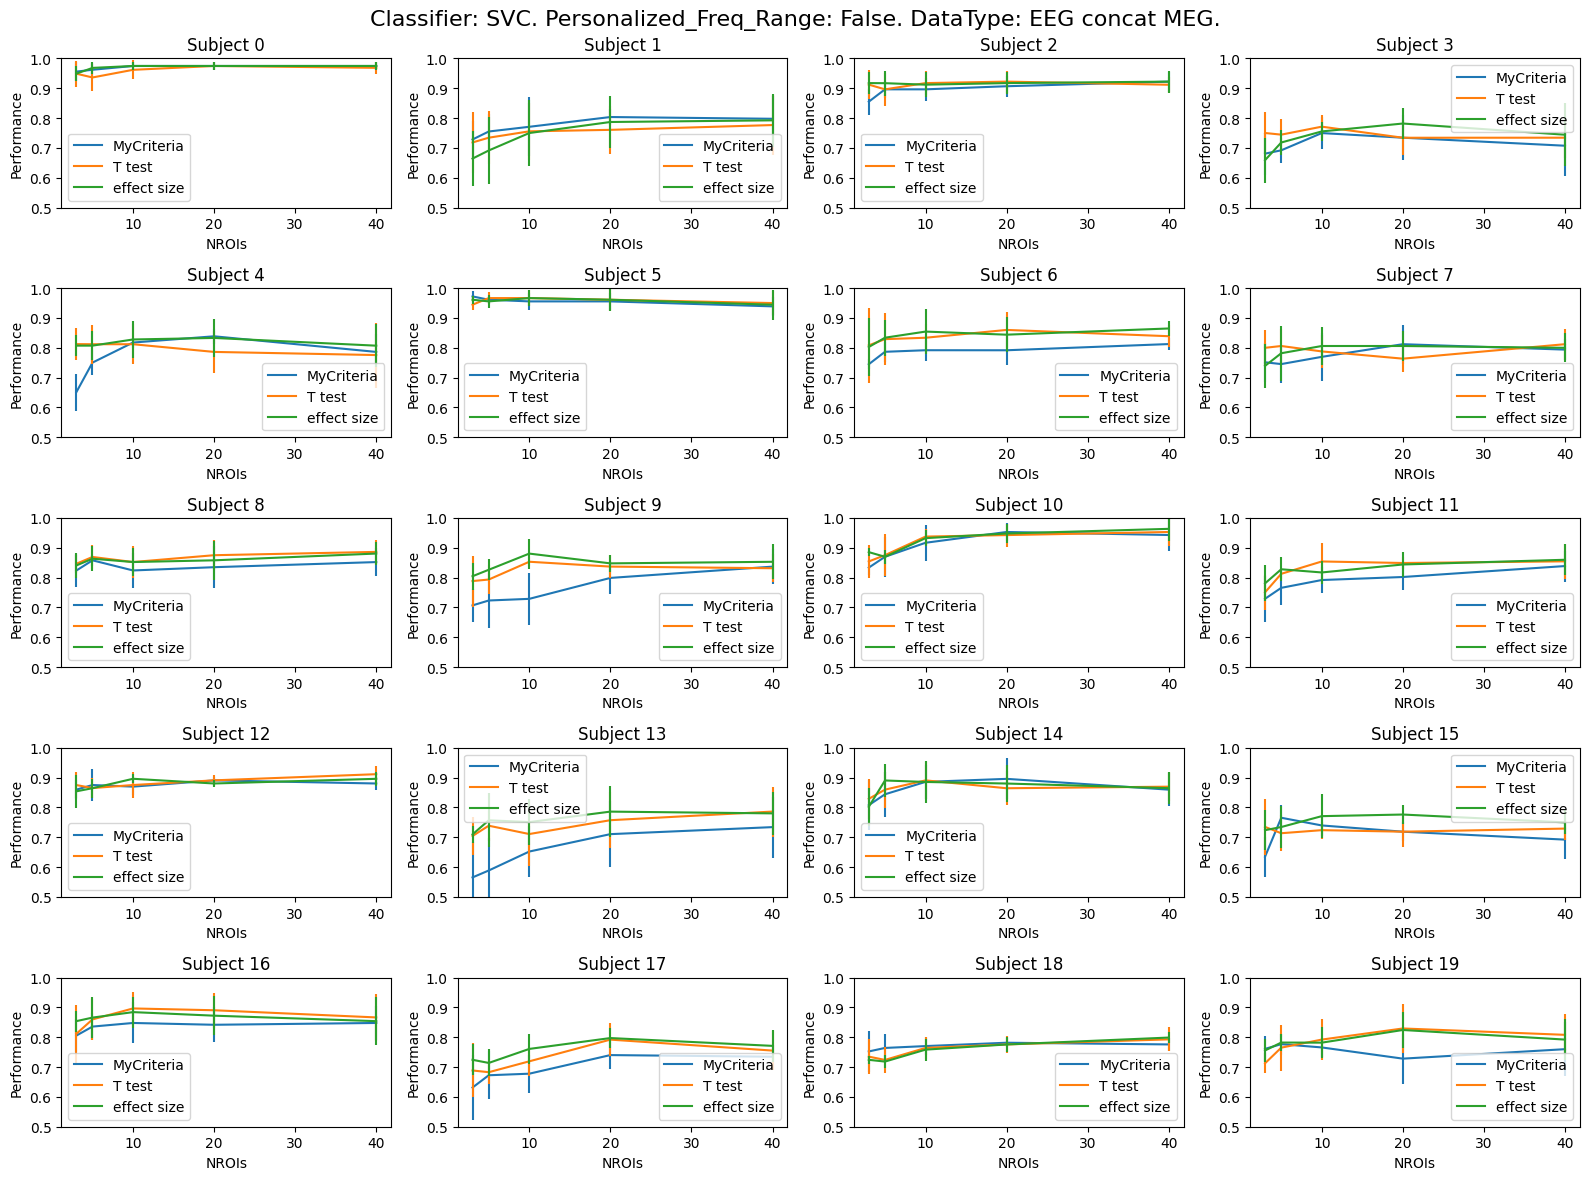

In [ ]:
# Different selections vs ROIs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"SVC","Personalized_Freq_Range":False,"DataType":"EEG concat MEG"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,  "Comments":"MyCriteria selection"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="MyCriteria")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,  "Comments": "T test selection mean power alpha beta"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="T test")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,  "Comments": "Cohen's d effect size selection"})
    allperf = np.array(list(rows["Performance"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="effect size")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Performance")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"EEG_concat_MEG_vs_EEG_vs_MEG_SVM.png")
plt.show()

## All subjects

### Different criteria

C:\Users\Dell_i5\AppData\Local\Temp\ipykernel_6240\3418149690.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", 20)


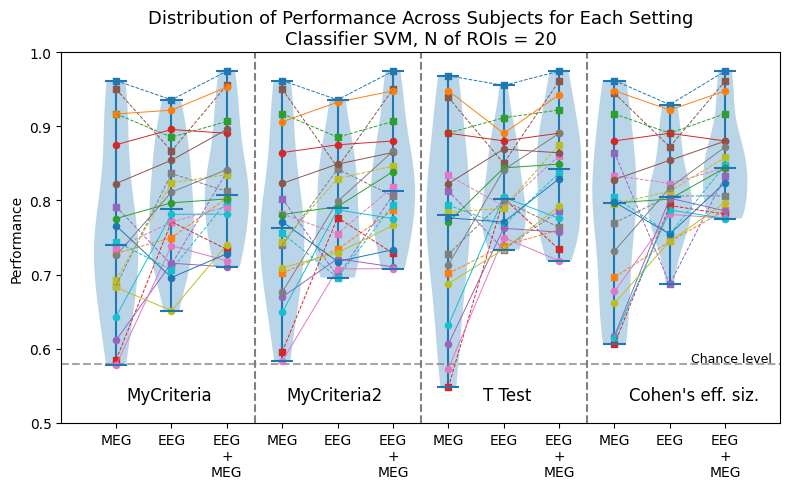

In [56]:
# All Subjects 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

chaanche_lvl = 0.58 # https://pubmed.ncbi.nlm.nih.gov/25596422/

VisualizigNROIs=20

PerData = pd.read_pickle("../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

num_performances_showed = 12
nps=num_performances_showed

x_positions = np.arange(nps)

cmap = plt.cm.get_cmap("tab20", 20)
styles=["--","solid"]
markes=["s","o"]
size=20


classifiers=["SVC"]*12
Datatypes=["MEG","EEG","EEG concat MEG"]*4
Comments=["MyCriteria selection"]*3  + ["MyCriteria2 selection"]*3  + ["T test selection mean power alpha beta"]*3 + ["Cohen's d effect size selection"]*3 #"Cohen's d effect size selection spectra starting from 3s"

x_ticklabels=[_.replace(" concat ","\n+\n") for _ in Datatypes]

all_perfs = []
dict_fixed_selection = {"Classifier":"SVC", "NROIs":VisualizigNROIs}
for subject in range(20):

    perfs_per_subject = []
    for setting in range(nps):
        # Extract performances
        rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,
                                                            "DataType":Datatypes[setting], "Comments":Comments[setting]})
        perfs_per_subject.append(np.array(list(rows["Performance"].values)).mean())
    all_perfs.append(perfs_per_subject)
    shifcolor=1 if subject>=10 else 0
    color=f"C{subject+shifcolor}"

    ax.scatter(x_positions, perfs_per_subject, marker=markes[subject//10],s=size,color=color)#facecolors='none',edgecolors=color
    ax.plot(x_positions[0:3], perfs_per_subject[0:3], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[3:6], perfs_per_subject[3:6], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[6:9], perfs_per_subject[6:9], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[9:12], perfs_per_subject[9:12], linestyle=styles[subject//10], linewidth=0.7,color=color)
    
    
all_perfs = np.array(all_perfs)   # shape (20 subjects, 9 settings)

#Violin plot
ax_violin = ax
violins = ax_violin.violinplot(
    all_perfs,
    positions=x_positions,
    showmeans=False,
    showmedians=True,
    widths=0.8,
)

for part in violins['bodies']+[violins['cbars']]:
    part.set_zorder(-20)
xlims = ax.get_xlim()
ax_violin.set_ylabel("Performance")
ax.hlines([chaanche_lvl], -1, 12, colors='grey', linestyles='dashed', label="Chance Level",zorder=-1, alpha=0.7)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_ticklabels)
ax.vlines([2.5,5.5,8.5], 0.5, 1, colors='gray', linestyles='dashed')
ax.set_ylim(0.5, 1)
ax.text(0.15, 0.1, f"MyCriteria", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.38, 0.1, f"MyCriteria2", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.62, 0.1, f"T Test", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.88, 0.1, f"Cohen's eff. siz.", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')

ax.text(1., 0.192, f"Chance level  ", transform=ax.transAxes, fontsize=9, verticalalignment='top',horizontalalignment='right')
ax.set_title(f"Distribution of Performance Across Subjects for Each Setting\nClassifier SVM, N of ROIs = {VisualizigNROIs}", fontsize=13)
ax.set_xlim(xlims)
plt.tight_layout()

#plt.savefig(savepathIMG+"Performance_vs_Setting_41_ROIs.png",dpi=300)
plt.show()

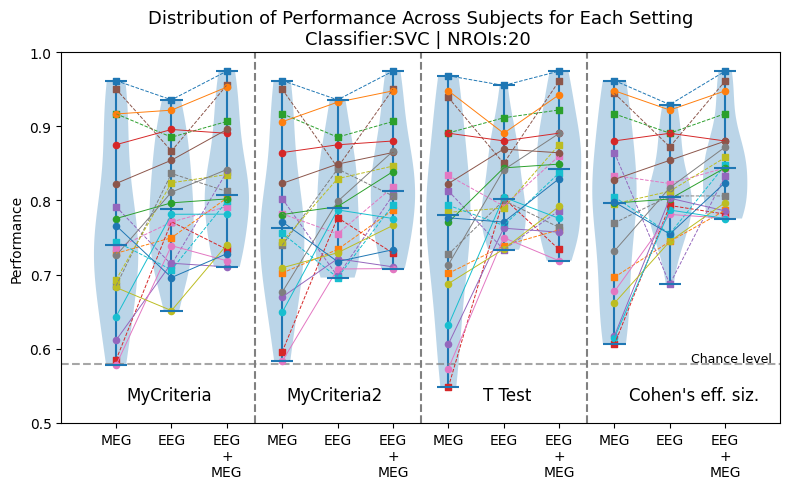

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
VisualizigNROIs=20
dict_fixed_selection = {"Classifier":"SVC", "NROIs":VisualizigNROIs}
divisioni = [0,3,6,9,12]
textes = ["MyCriteria", "MyCriteria2", "T Test", "Cohen's eff. siz."]
textes_x_positions = [0.15, 0.38, 0.62, 0.88]
savepathIMG+"Performance_vs_Setting_41_ROIs.png"
Datatypes=["MEG","EEG","EEG concat MEG"]*4
Comments=["MyCriteria selection"]*3  + ["MyCriteria2 selection"]*3  + ["T test selection mean power alpha beta"]*3 + ["Cohen's d effect size selection"]*3 #"Cohen's d effect size selection spectra starting from 3s"
x_ticklabels = ["MEG","EEG","EEG\n+\nMEG"]*4
dict_per_setting = {"DataType":Datatypes, "Comments":Comments}

plot_violin_all_subj(PerData,  12,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions,
                  divisioni  ,hlines_positions=[],
                  track_subjects=True,  savepath=False)







### Vs N ROIs

C:\Users\Dell_i5\AppData\Local\Temp\ipykernel_6240\1358134687.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", 20)


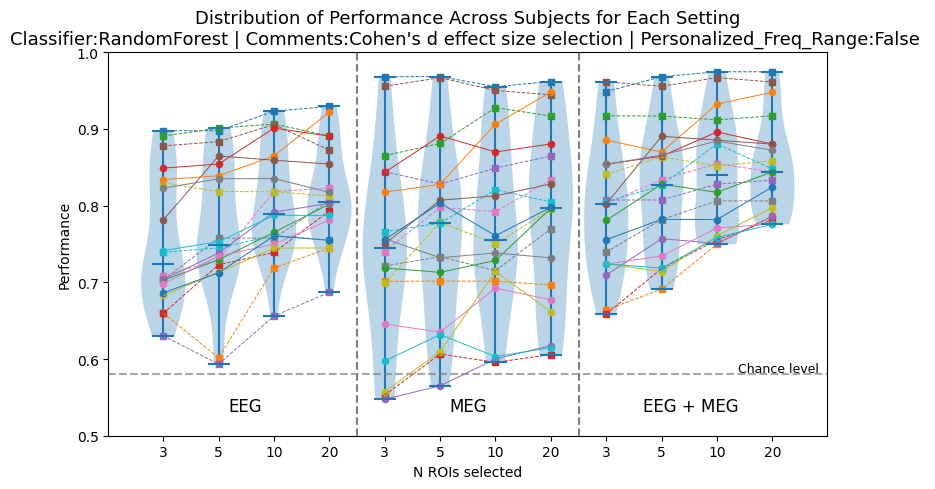

{"Cohen's d effect size selection",
 "Cohen's d effect size selection spectra starting from 3s",
 'MyCriteria selection',
 'MyCriteria2 selection',
 'T test selection mean power alpha beta'}

In [ ]:
# All Subjects  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

chaanche_lvl = 0.58 # https://pubmed.ncbi.nlm.nih.gov/25596422/



PerData = pd.read_pickle("../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

num_performances_showed = 12
nps=num_performances_showed

x_positions = np.arange(nps)

cmap = plt.cm.get_cmap("tab20", 20)
styles=["--","solid"]
markes=["s","o"]
size=20


VisualizigNROIs=[3,5,10,20]
Datatypes=["EEG"]* len(VisualizigNROIs) + ["MEG"]* len(VisualizigNROIs) + ["EEG concat MEG"]* len(VisualizigNROIs)
VisualizigNROIs=VisualizigNROIs*3 # 3 is Datatype
classifiers=["SVC"]*4*3


x_ticklabels=[_ for _ in VisualizigNROIs]

all_perfs = []
dict_fixed_selection = {"Classifier":"RandomForest", "Comments":"Cohen's d effect size selection",  "Personalized_Freq_Range":False }
for subject in range(20):

    perfs_per_subject = []
    for setting in range(nps):
        # Extract performances
        rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":classifiers[setting],
                                                            "DataType":Datatypes[setting], "NROIs":VisualizigNROIs[setting]})
        perfs_per_subject.append(np.array(list(rows["Performance"].values)).mean())
    all_perfs.append(perfs_per_subject)
    shifcolor=1 if subject>=10 else 0
    color=f"C{subject+shifcolor}"

    ax.scatter(x_positions, perfs_per_subject, marker=markes[subject//10],s=size,color=color)#facecolors='none',edgecolors=color
    ax.plot(x_positions[0:4], perfs_per_subject[0:4], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[4:8], perfs_per_subject[4:8], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[8:12], perfs_per_subject[8:12], linestyle=styles[subject//10], linewidth=0.7,color=color)
    
    
all_perfs = np.array(all_perfs)   # shape (20 subjects, 9 settings)

#Violin plot
ax_violin = ax
violins = ax_violin.violinplot(
    all_perfs,
    positions=x_positions,
    showmeans=False,
    showmedians=True,
    widths=0.8,
)

for part in violins['bodies']+[violins['cbars']]:
    part.set_zorder(-20)
xlims = ax.get_xlim()
ax_violin.set_ylabel("Performance")
ax.hlines([chaanche_lvl,], -1, 12, colors='grey', linestyles='dashed', label="Chance Level",zorder=-1, alpha=0.7)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_ticklabels)
ax.vlines([3.5,7.5], 0.5, 1, colors='gray', linestyles='dashed')
ax.set_ylim(0.5, 1)
ax.text(0.19, 0.1, f"EEG", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.5, 0.1, f"MEG", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.81, 0.1, f"EEG + MEG", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')

ax.text(1., 0.192, f"Chance level  ", transform=ax.transAxes, fontsize=9, verticalalignment='top',horizontalalignment='right')
title = f"Distribution of Performance Across Subjects for Each Setting\n"
for key,value in dict_fixed_selection.items():
    title+= f"{key}:{value} | "
title=title[:-2]
ax.set_title(title, fontsize=13)
ax.set_xlim(xlims)
ax.set_xlabel("N ROIs selected")
plt.tight_layout()

#plt.savefig(savepathIMG+"Performance_vs_Setting_41_ROIs.png",dpi=300)
plt.show()
set(PerData["Comments"])

## Brain plots

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows, plot_brain, read_ranks_subect_on_folds, sort_rank
from matplotlib.colors import LinearSegmentedColormap

# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,
colors = {"EEG":"green","MEG":"blue"}
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]


for DataType in ["EEG","MEG"]: #["EEG","MEG"]:
    for N_best_ROIs in[5,10,20,30]:  #[5,10,20,30]:
        cmap = LinearSegmentedColormap.from_list("wt", ["white",colors[DataType]])
        
        how_many_times = {}
        for regione in range(68):
            how_many_times[regione] = 0
        num_subj_at_least_1_right, num_subj_at_least_1_left = (0,0)
        for subject in range(20):
            ranks_subject = read_ranks_subect_on_folds("../Results/RegionSelection/" \
            f"Selected_regions_MultiTtest_{DataType}_among_5_folds_training_selected.pkl", subject)
            # take first
            ranks_subject_sorted = sort_rank(ranks_subject)[1]
            at_least_1_left, at_least_1_right = (0,0)
            for migiori_regioni in range(N_best_ROIs):
                regione_ora = ranks_subject_sorted[migiori_regioni]
                how_many_times[regione_ora] +=  1 
                # controllo se nel soggetto ha almeno 1 regione tra quelle importanti di destra o sinistra
                if regione_ora in Interesting_regions_left:
                    at_least_1_left = 1
                    #print(subject, regione_ora)
                if regione_ora in Interesting_regions_right:
                    at_least_1_right = 1

            num_subj_at_least_1_right += at_least_1_right
            num_subj_at_least_1_left += at_least_1_left

                

        crs = [cmap(_/max(how_many_times.values())) for _ in how_many_times.values()]

        vvs = ['lateral','medial','rostral','caudal','dorsal']
        my_brain=plot_brain([int(_) for _ in how_many_times.keys()],
                            brain_object_dict={"title":f"{DataType}_NROIs{N_best_ROIs}","hemi": "both", "views":vvs}, colors=crs,
                            )
        plotter = my_brain._renderer.plotter

        # STEP 2 — Add text using the plotter (it now applies to renderer 0)
        plotter.add_text(
            f" Most selected region \n is selected in\n {max(how_many_times.values())} subjects\n on 20 subjects total",
            position="upper_left",
            font_size=10,
            color="black",
        )

        my_brain.add_text(0,0.3,f" T test alpha beta crit\n {DataType}\n Num_best_ROIs={N_best_ROIs}",font_size=10,)
        my_brain.add_text(0.65,0.3,f"Num of subject with \nat least 1 region in\nleft important: {num_subj_at_least_1_left}\nright important: {num_subj_at_least_1_right}",font_size=8,)

        savepathIMG = "../Images/Brain/Region_selection_criteria/"
        #my_brain.save_image(savepathIMG+f"Brain_{DataType}_NROIs_{N_best_ROIs}_Ttest_alpha_beta_criteria.png")



Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/

Context leak detected, msgtracer returned -1


#